In [ ]:
import os
import re
import matplotlib.pyplot as plt
import pandas as pd
import scipy.optimize as opt
import numpy as np
from pathlib import Path
from typing import NamedTuple, List
from dataclasses import dataclass

In [2]:
os.chdir(Path("D:/PhysicsResearch/projects/Laboratorio 3/Clase 3 (25-8)"))

# Determinación de tiempo característico para RC

In [3]:
@dataclass
class Experiment:
    R: float
    data: pd.DataFrame
    label: str
    p0: list
    interval: tuple
    taudet: float = 0.0

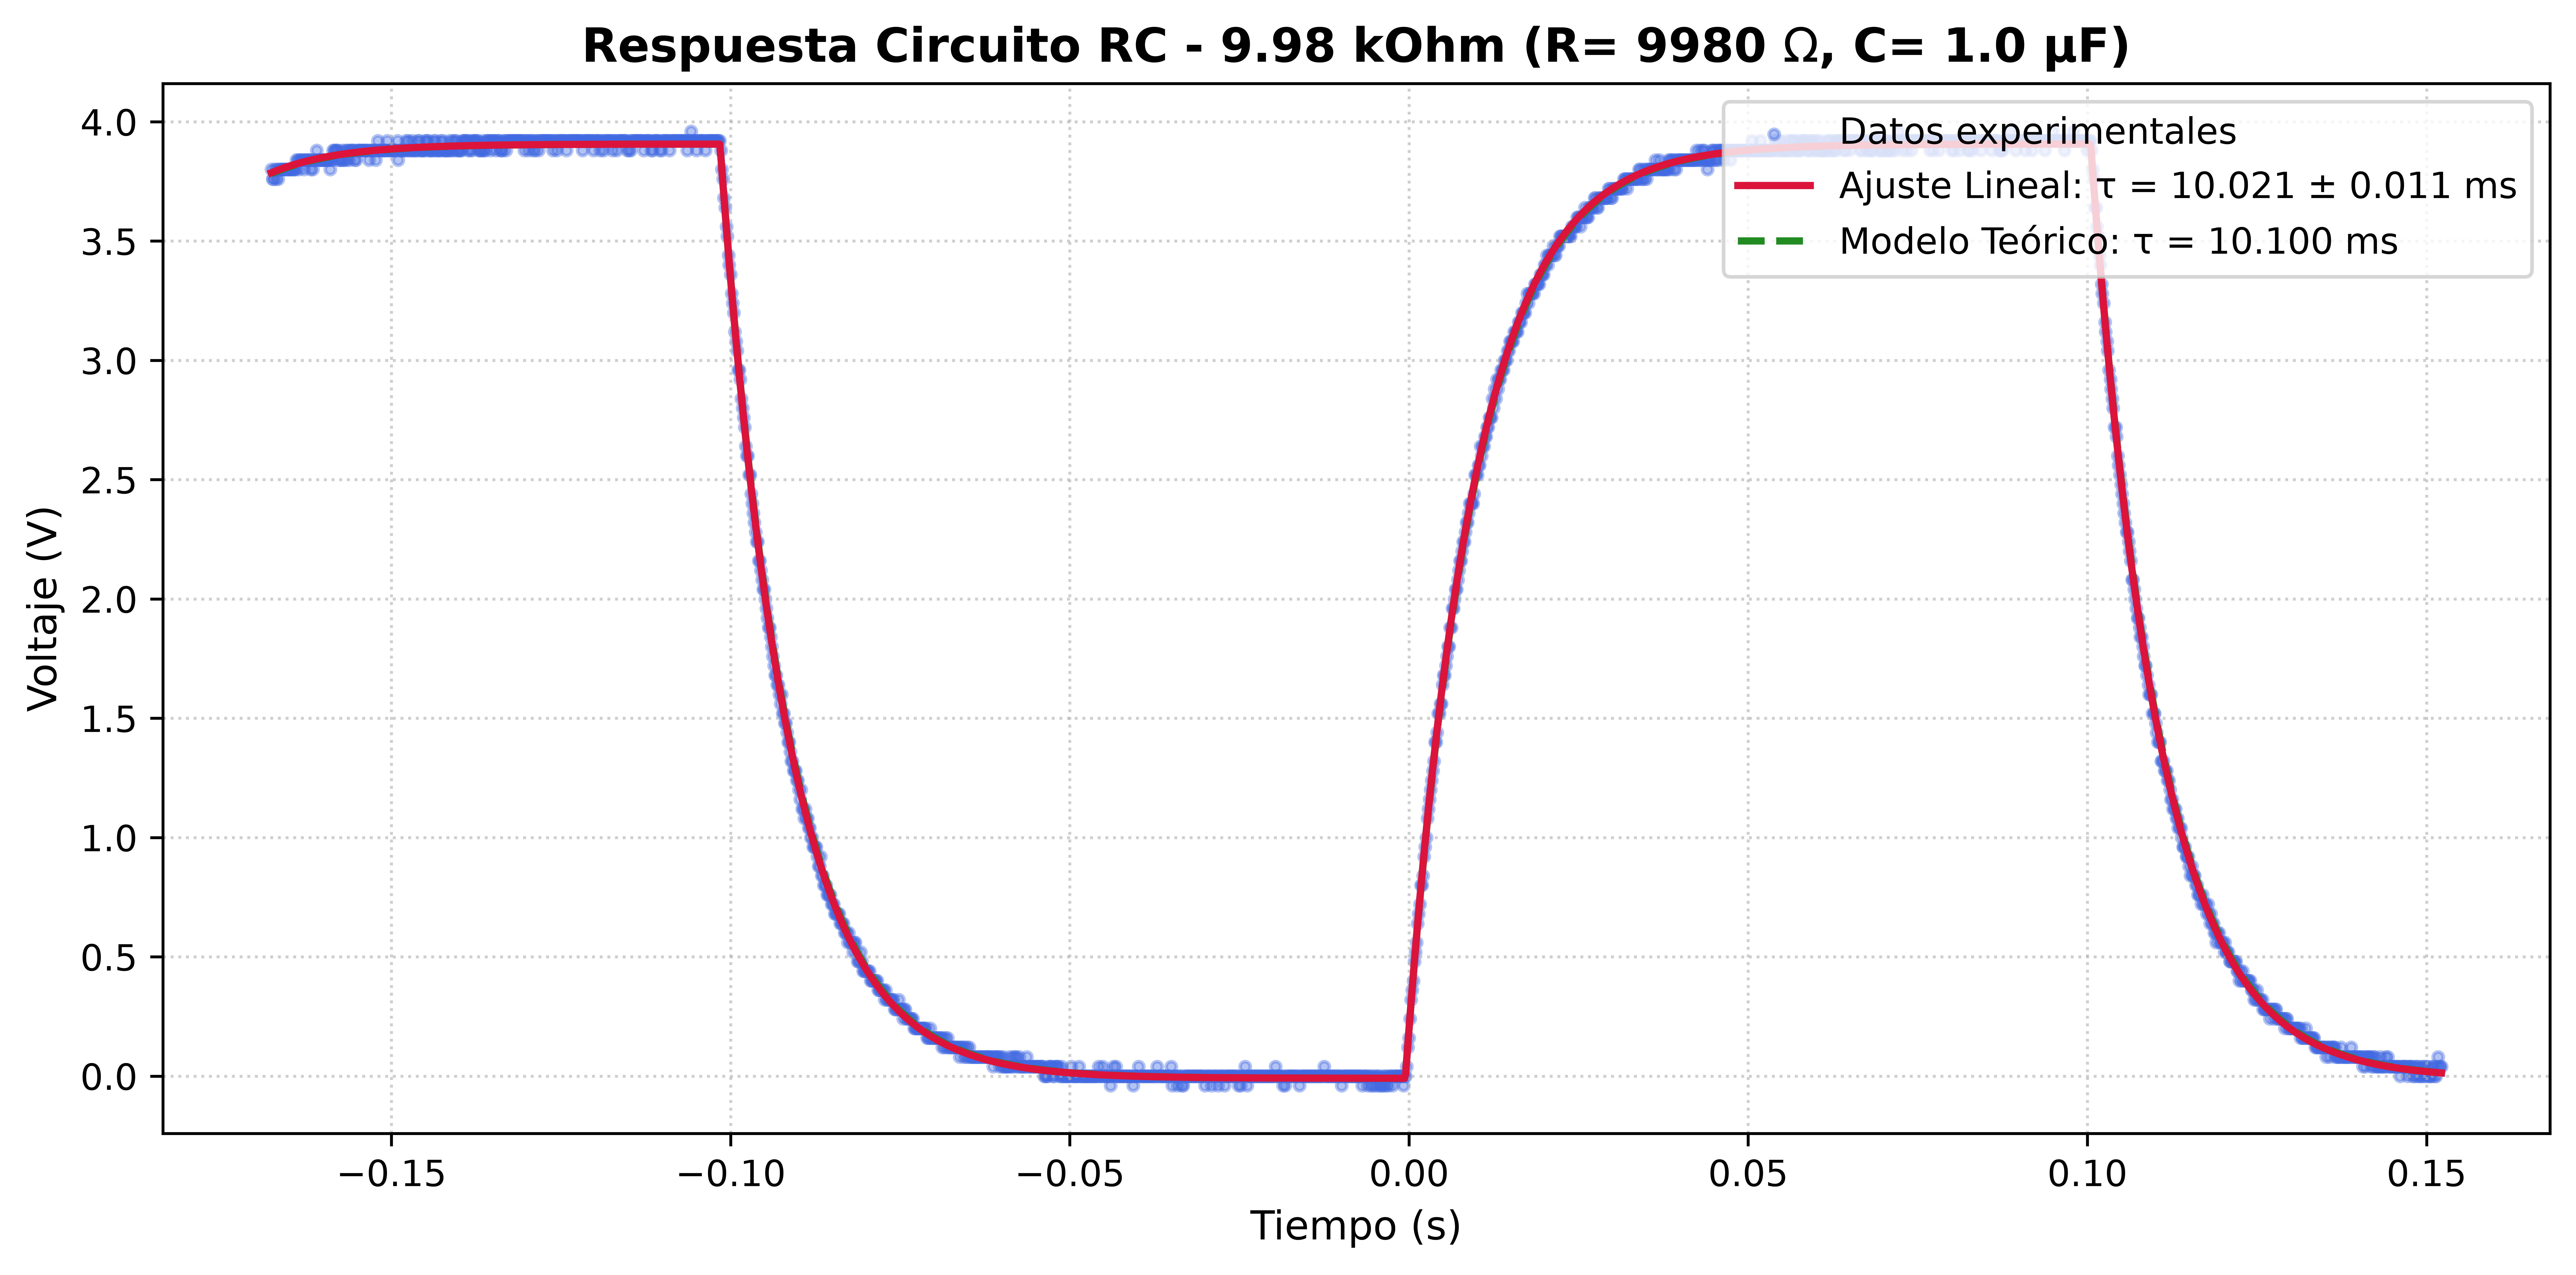

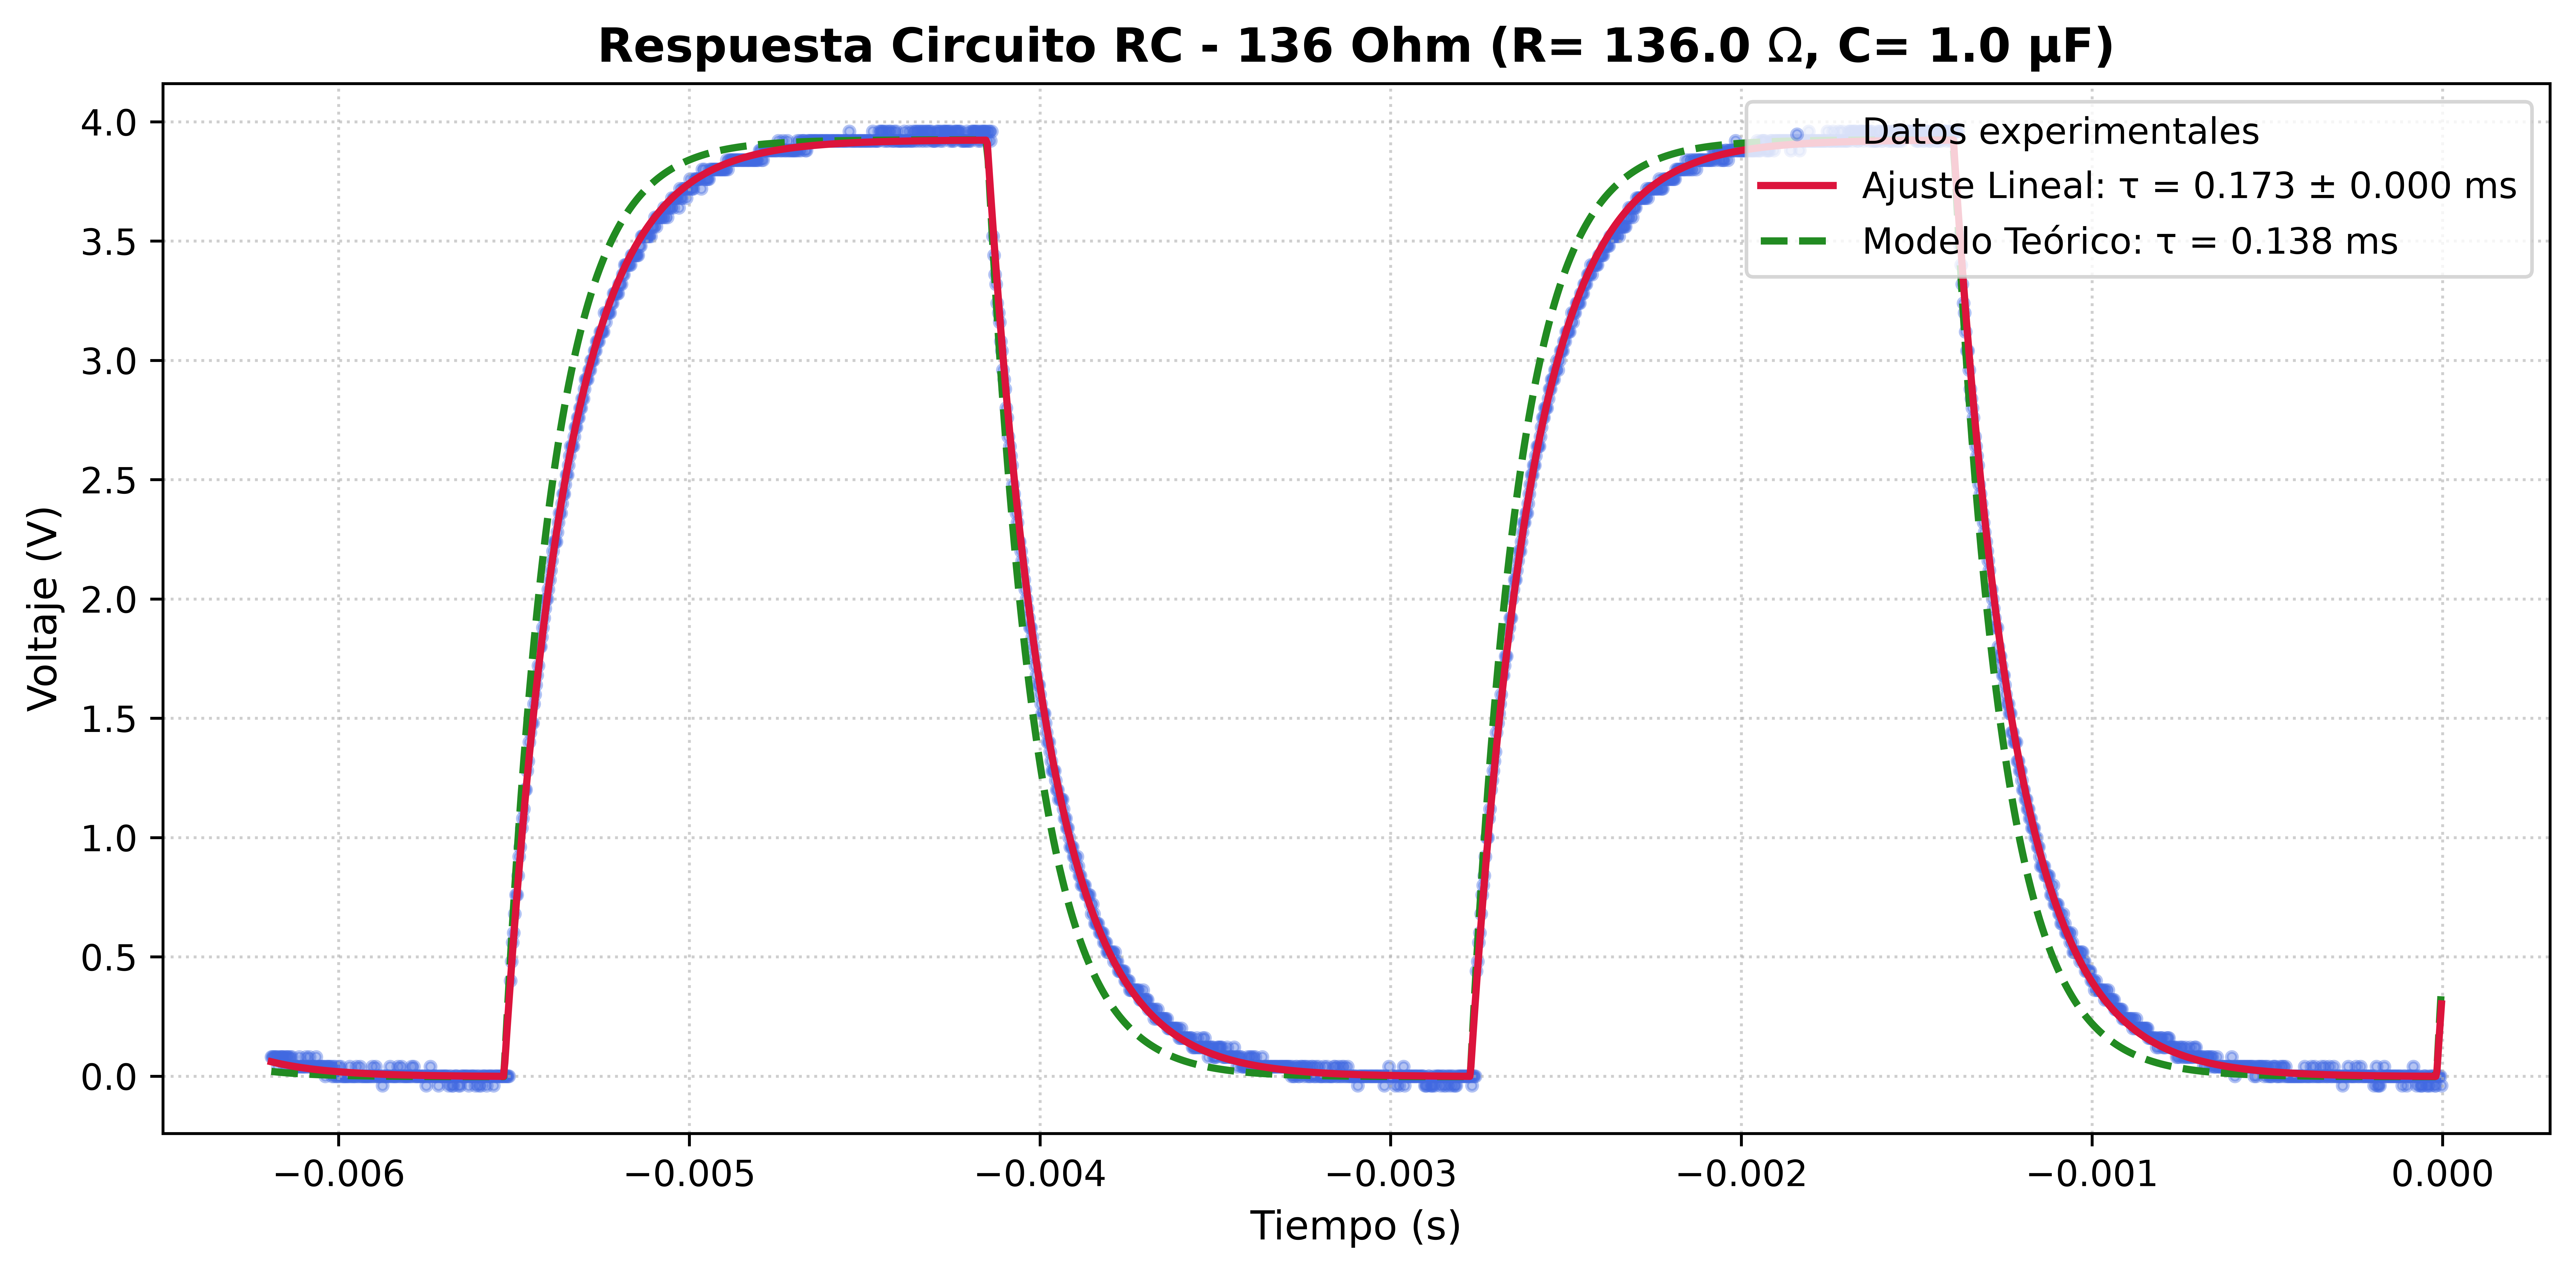

In [4]:
C = 1.012e-6 # Faradios

experiments: list[Experiment] = [

    Experiment(
        R=9980,
        data=pd.read_csv("Determinación de Tau/9.98kOhm.CSV", skiprows=15, dtype={"TIME": float, "CH1": float}),
        label="9.98 kOhm",
        p0=[0.01, 4.0, 0.0, 0.2, 0.0],
        interval=(-1, 1),
        taudet=0
    ),
    Experiment(
        R=136.0,
        data=pd.read_csv("Determinación de Tau/136.0Ohm.CSV", skiprows=15, dtype={"TIME": float, "CH1": float}),
        label="136 Ohm",
        p0=[0.00014, 4.0, 0.0, 0.00285, 0.0],
        interval=(-1, 0),
        taudet=0
    )
]

def modelo(t, tau, V_max, V_min, T, t0):

    def rc_charge(t, tau, V_max, V_min, t0):
        return np.where(
            t < t0, V_min, V_min + (V_max - V_min) * (1 - np.exp(-(t - t0) / tau))
        )


    def rc_discharge(t, tau, V_max, V_min, t0):
        return np.where(
            t < t0, V_max, V_min + (V_max - V_min) * np.exp(-(t - t0) / tau)
        )

    t_mod = (t - t0) % T
    half_T = T / 2.0

    V = np.where(
        t_mod < half_T,
        V_min + (V_max - V_min) * (1 - np.exp(-t_mod / tau)),
        V_min + (V_max - V_min) * np.exp(-(t_mod - half_T) / tau),
    )

    return V

for exp in experiments:
    R = exp.R
    data = exp.data
    label = exp.label
    p0 = exp.p0
    interval = exp.interval

    tau_teo = R*C

    t = data["TIME"].to_numpy()
    V = data["CH1"].to_numpy()

    mask = (t >= interval[0]) & (t <= interval[1])
    t = t[mask]
    V = V[mask]

    popt, pcov = opt.curve_fit(modelo, t, V, p0=p0)

    tau_fit = popt[0]
    tau_fit_err = np.sqrt(np.diag(pcov))[0]

    p_teo = [tau_teo, *popt[1:]]

    t_smooth = np.linspace(t[0], t[-1], 1000)

    fig, ax = plt.subplots(figsize = (10,5), dpi = 1000)
    ax.scatter(t, V, label="Datos experimentales", color="royalblue", alpha=0.4, s=8, zorder=1)
    ax.plot(t, modelo(t, *popt), label=f"Ajuste Lineal: τ = {tau_fit*1e3:.3f} ± {tau_fit_err*1e3:.3f} ms", color="crimson", linewidth=2, zorder=3)
    ax.plot(t_smooth, modelo(t_smooth, *p_teo), label=f"Modelo Teórico: τ = {tau_teo*1e3:.3f} ms", color="forestgreen", linestyle="--", linewidth=2, zorder=2)

    ax.set_title(f"Respuesta Circuito RC - {label} (R= {R} $ \\Omega$, C= {C*1e6:.1f} μF)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Tiempo (s)", fontsize=11)
    ax.set_ylabel("Voltaje (V)", fontsize=11)
    ax.legend(loc="upper right", frameon = True, fontsize=10)
    ax.grid(True, alpha=0.6, linestyle=":")

    plt.tight_layout()
    plt.show()

    exp.taudet = tau_fit

In [5]:
taudeterminado = experiments[1].taudet
print(taudeterminado)
tauesperado = experiments[1].R * C
print(tauesperado)
resistencia_salida = (taudeterminado - tauesperado)/C
print(f"La resistencia de salida es: {resistencia_salida} Ω")

resistencia_r = (taudeterminado/C)-50
print(f"La resistencia del circuito es: {resistencia_r} Ω")

0.00017250089026946307
0.000137632
La resistencia de salida es: 34.455425167453626 Ω
La resistencia del circuito es: 120.45542516745363 Ω


# 

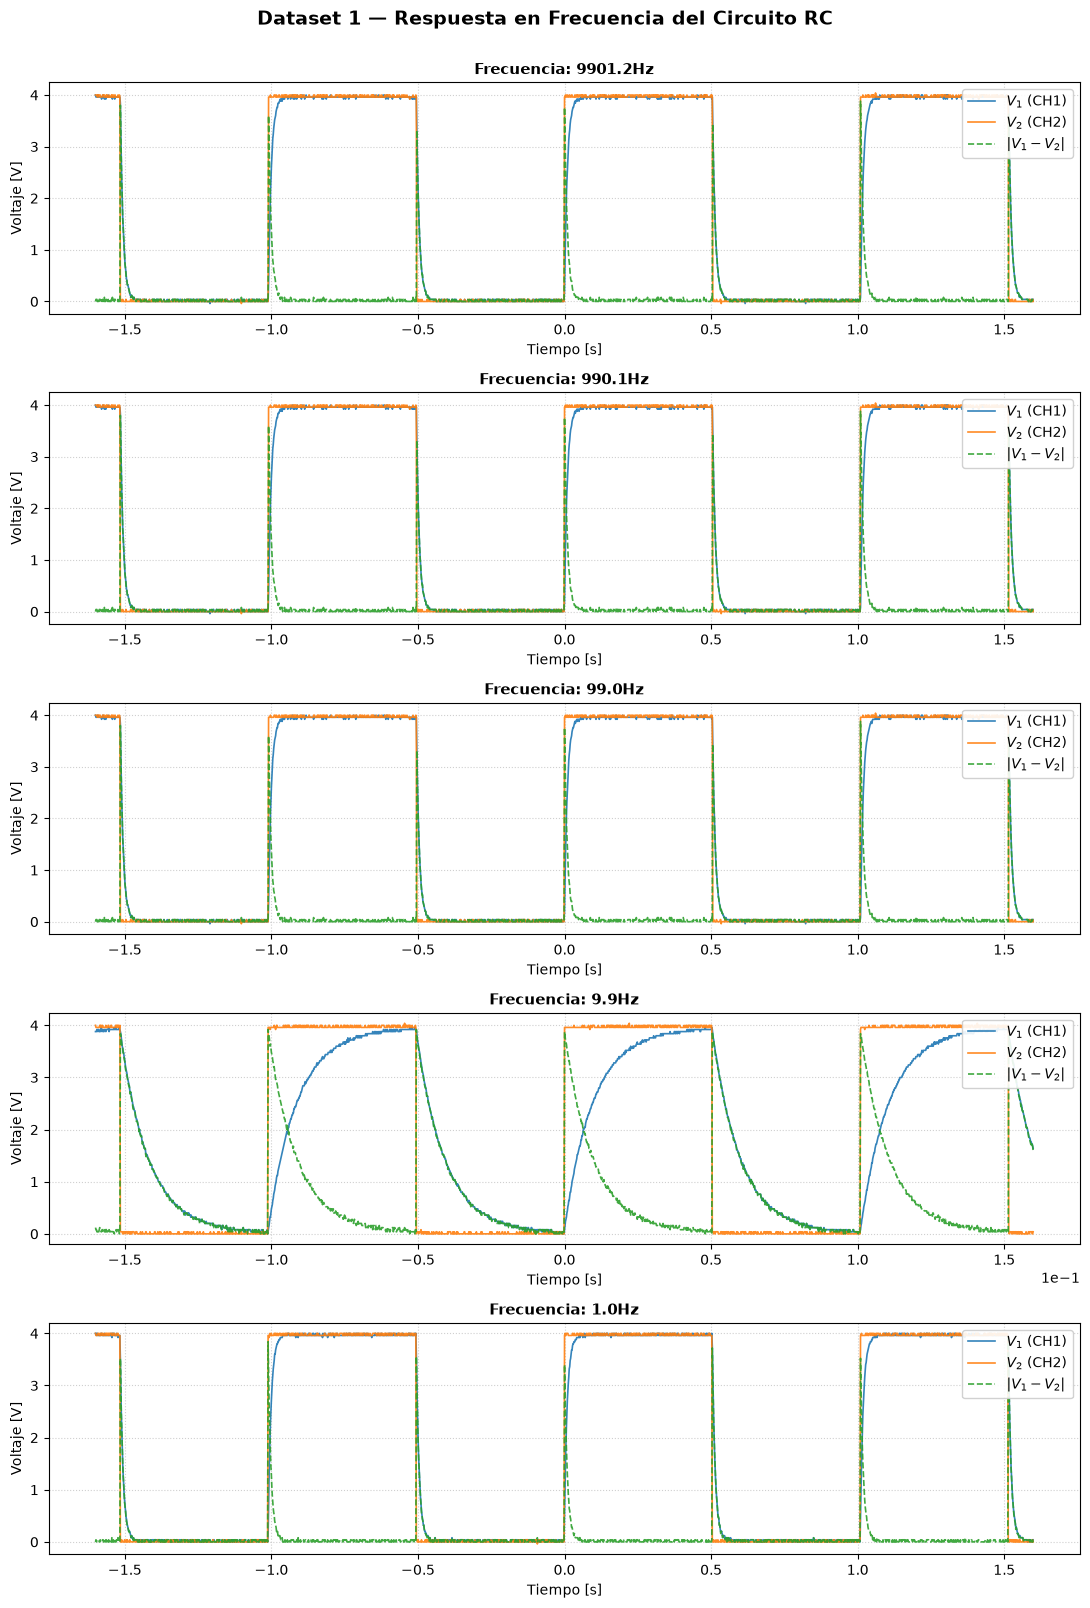

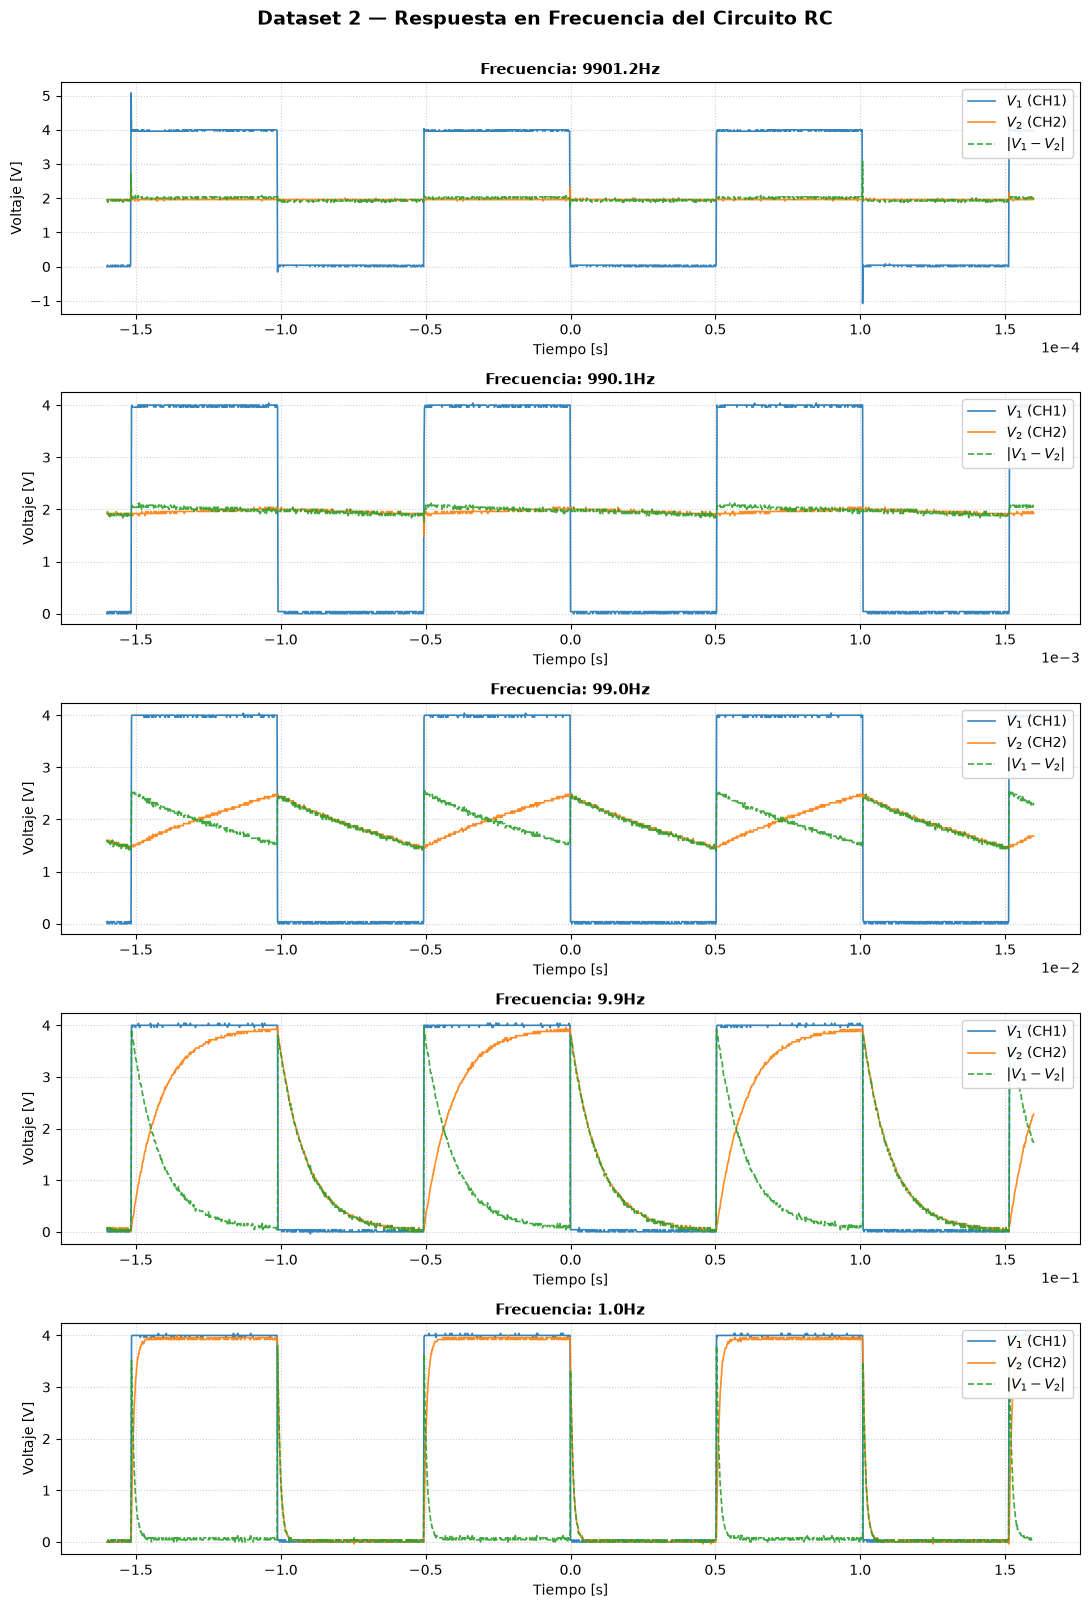

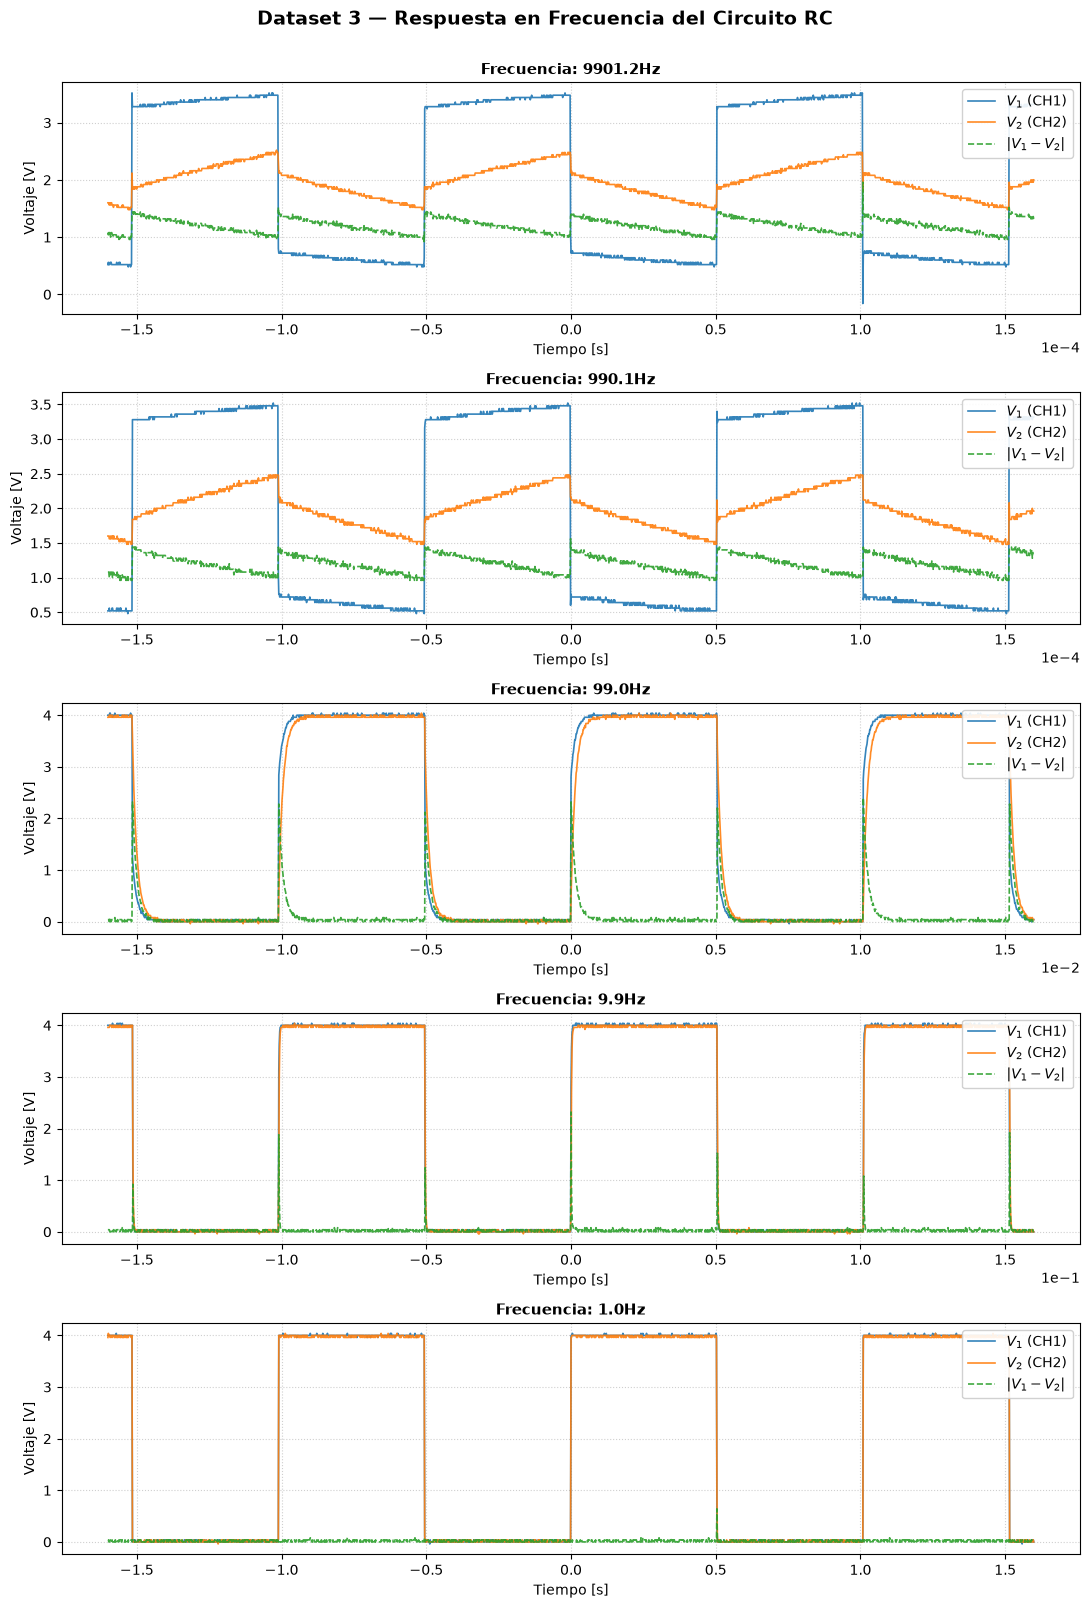

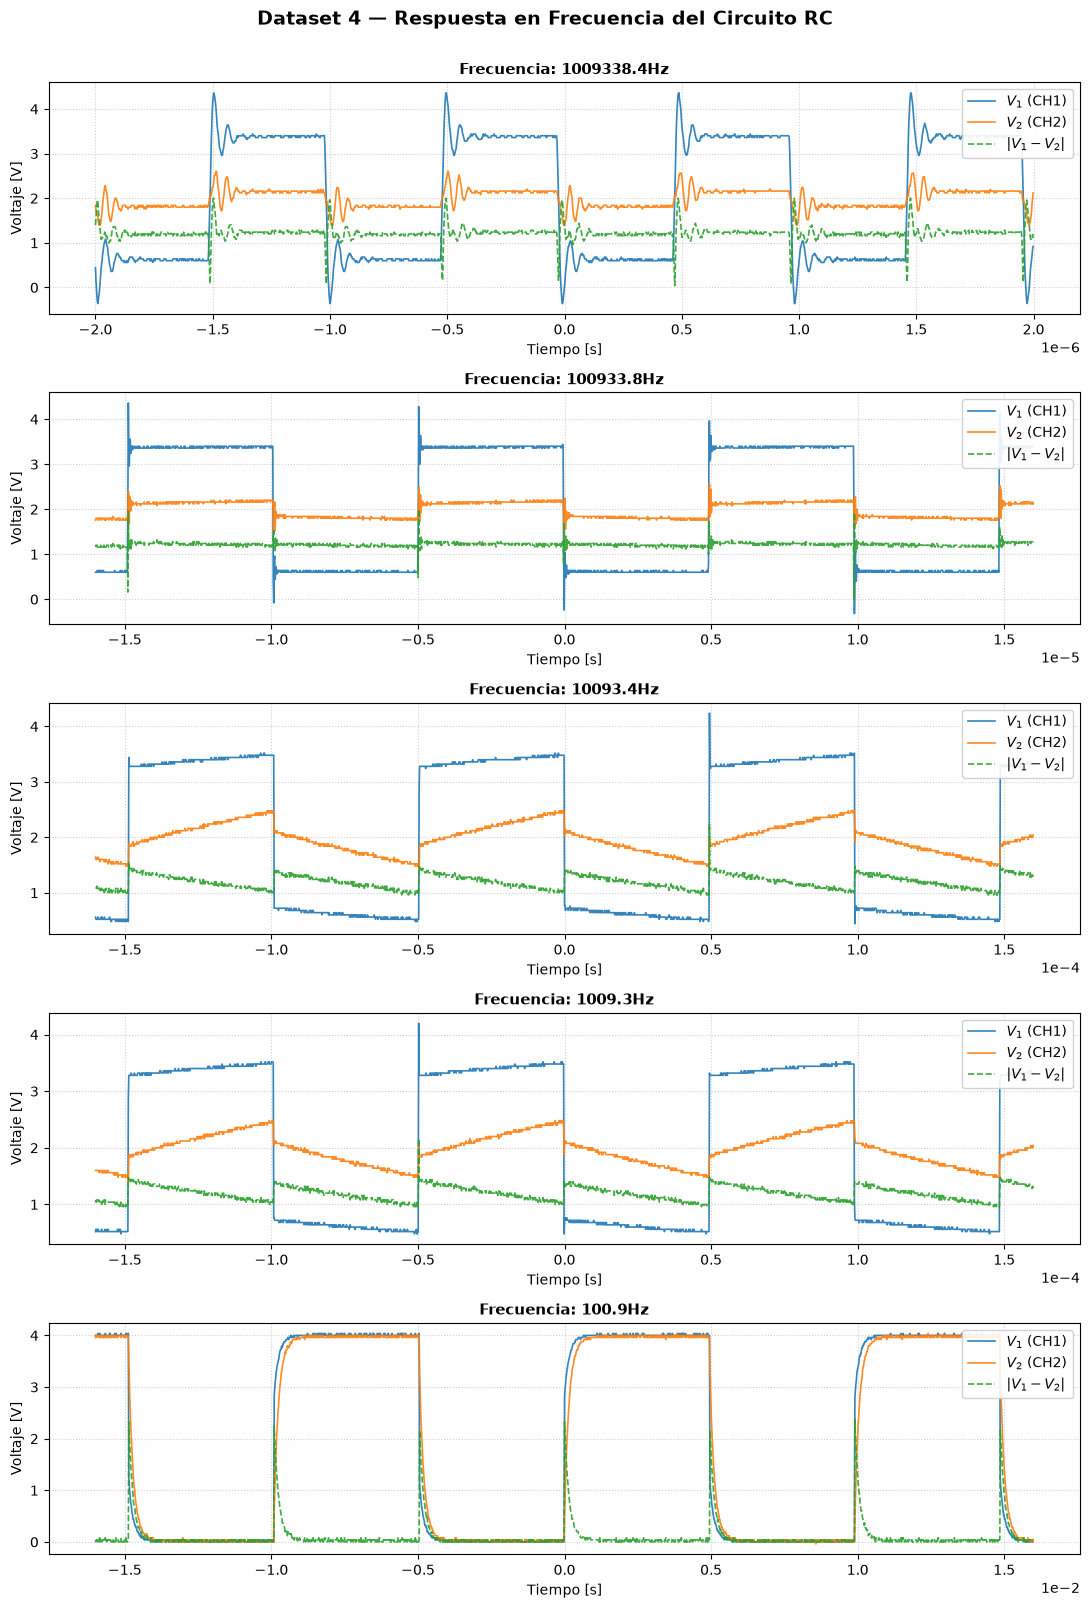

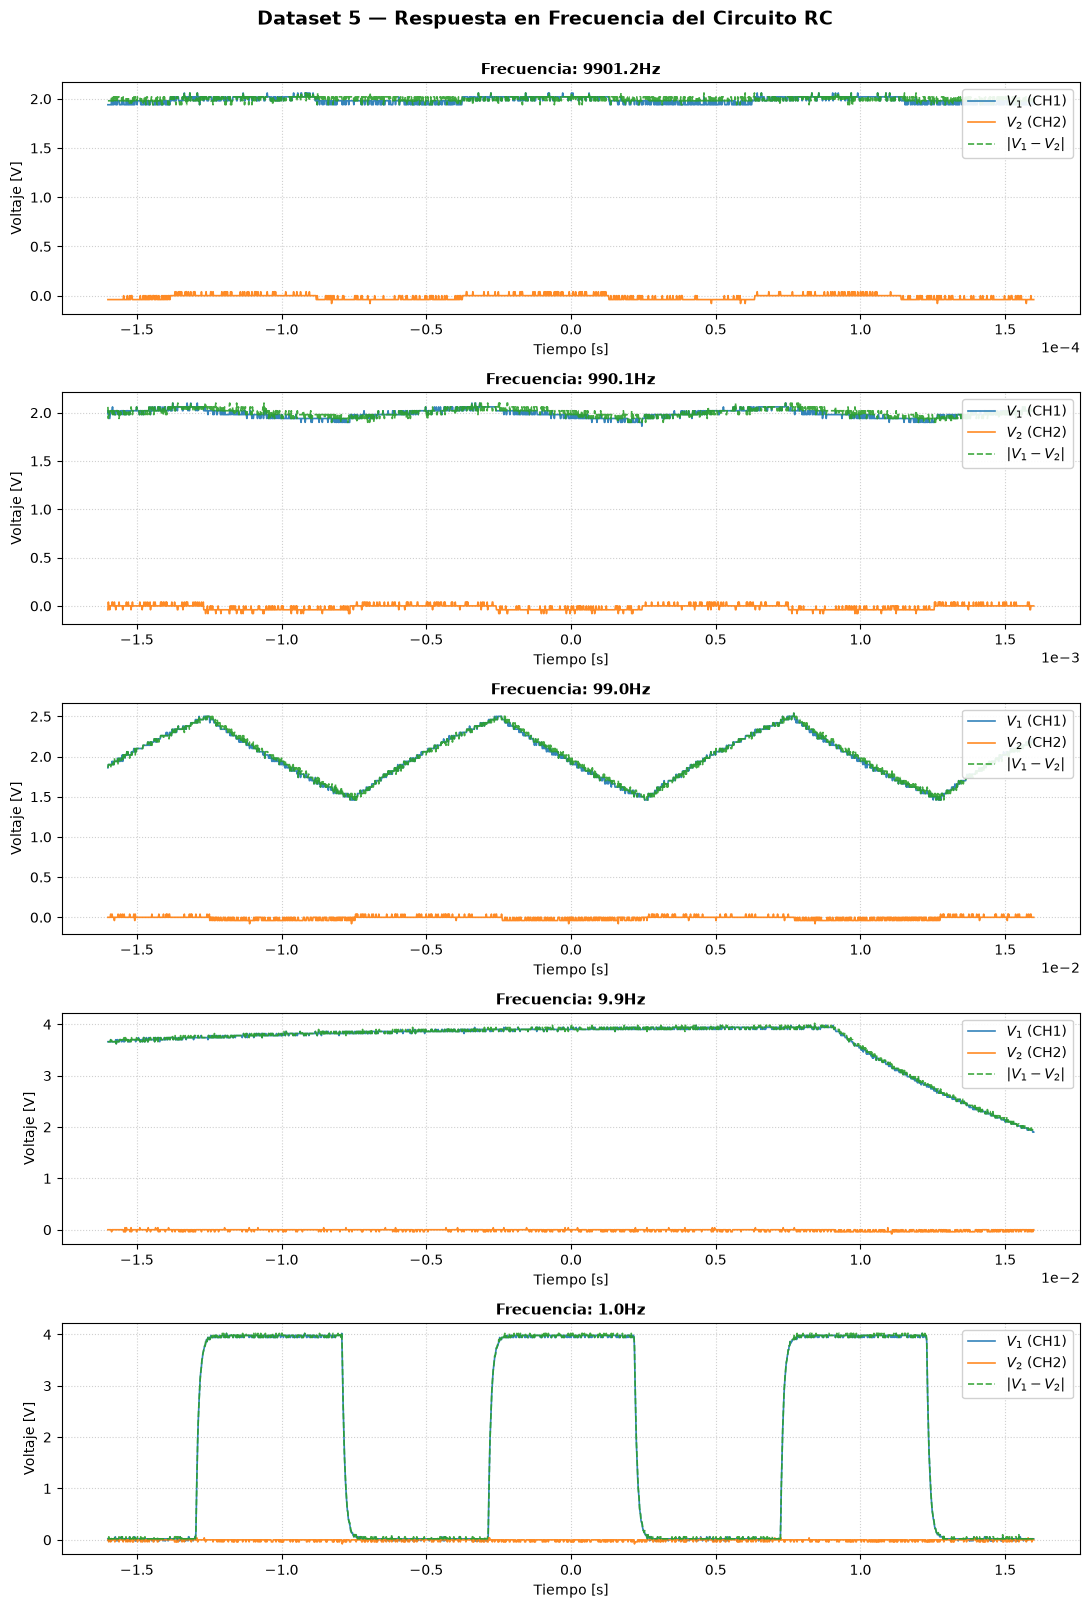

In [6]:
datasets = [1, 2, 3, 4, 5]

for ds in datasets:
    file_ch1 = f"{ds}CH1.csv"
    file_ch2 = f"{ds}CH2.csv"

    if not Path(file_ch1).exists() or not Path(file_ch2).exists():
        print(f"[!] Saltando Dataset {ds}: no se encontró {file_ch1} o {file_ch2}")
        continue

    # Lectura de los archivos
    df1 = pd.read_csv(file_ch1)
    df2 = pd.read_csv(file_ch2)

    # 5 frecuencias = 10 columnas (de a pares: t, V)
    n_freqs = min(df1.shape[1], df2.shape[1]) // 2

    # Creamos una figura de 5 subplots verticales para este dataset
    fig, axes = plt.subplots(n_freqs, 1, figsize=(11, 3.2 * n_freqs), sharex=False)
    fig.suptitle(
        f"Dataset {ds} — Respuesta en Frecuencia del Circuito RC",
        fontsize=14,
        fontweight="bold",
        y=1.002,
    )

    if n_freqs == 1:
        axes = [axes]

    for i in range(n_freqs):
        ax = axes[i]

        # Extraer nombres de columnas y datos
        col_t1, col_v1 = df1.columns[2 * i], df1.columns[2 * i + 1]
        col_t2, col_v2 = df2.columns[2 * i], df2.columns[2 * i + 1]

        # Limpiar NaNs y sincronizar longitudes
        t = df1[col_t1].dropna().values
        v1 = df1[col_v1].dropna().values
        v2 = df2[col_v2].dropna().values

        min_len = min(len(t), len(v1), len(v2))
        t, v1, v2 = t[:min_len], v1[:min_len], v2[:min_len]

        # Resta en módulo: |V1 - V2|
        v_diff = np.abs(v1 - v2)

        # Extraer texto de la frecuencia para el título (ej: "9901.2Hz")
        freq_str = col_v1.split("_")[-1]

        # Graficar señales
        ax.plot(
            t, v1, label=r"$V_1$ (CH1)", color="tab:blue", lw=1.2, alpha=0.9
        )
        ax.plot(
            t, v2, label=r"$V_2$ (CH2)", color="tab:orange", lw=1.2, alpha=0.9
        )
        ax.plot(
            t,
            v_diff,
            label=r"$|V_1 - V_2|$",
            color="tab:green",
            ls="--",
            lw=1.2,
            alpha=0.9,
        )

        ax.set_title(f"Frecuencia: {freq_str}", fontsize=11, fontweight="bold")
        ax.set_xlabel("Tiempo [s]", fontsize=10)
        ax.set_ylabel("Voltaje [V]", fontsize=10)
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.legend(loc="upper right", framealpha=0.9)
        ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

    plt.tight_layout()
    plt.show()

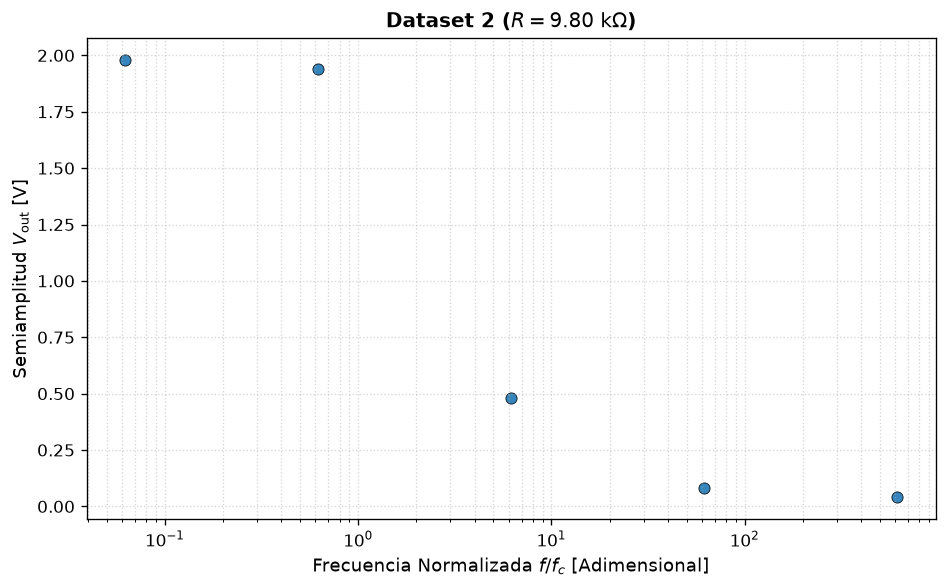

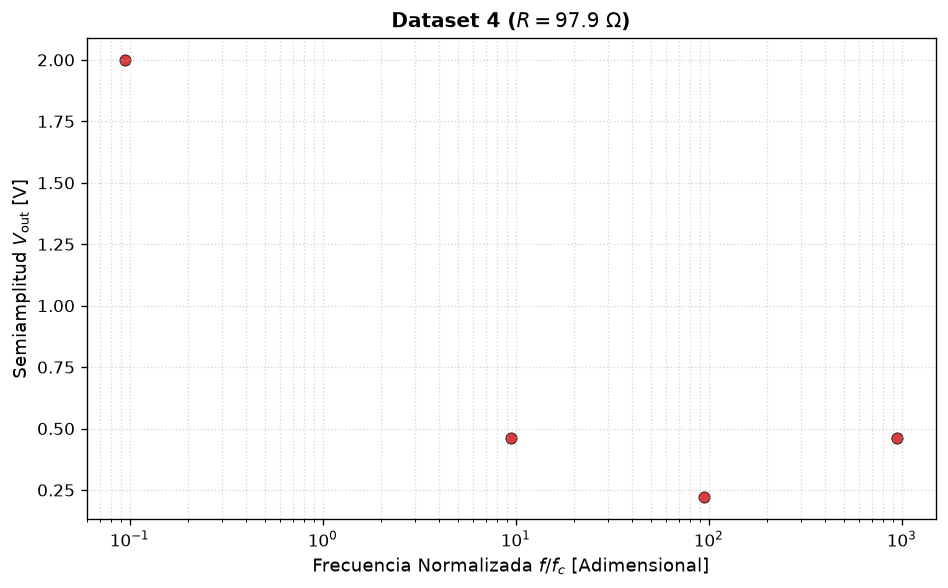

In [10]:
C_NOM = 1.012e-6  # Capacidad nominal [F]
R_GEN = 50.0  # Resistencia interna del generador [Ohm]

DATASETS = {
    2: {
        "title": r"Dataset 2 ($R = 9.80\text{ k}\Omega$)",
        "R_eff": 9800.0,
        "color": "tab:blue",
        "filter_spurious": False,
    },
    4: {
        "title": r"Dataset 4 ($R = 97.9\ \Omega$)",
        "R_eff": 97.9 + R_GEN,  # Corrección por impedancia del generador
        "color": "tab:red",
        "filter_spurious": True,  # Remueve el punto espurio en f ≈ 1 kHz
    },
}


# =============================================================================
# 2. EXTRACCIÓN DE DATOS
# =============================================================================
def load_dataset(ds_idx, filter_spurious=False):
    """Extrae frecuencias y semiamplitudes (Vpp / 2) de un archivo CSV."""
    file_path = Path(f"{ds_idx}CH2.csv")
    if not file_path.exists():
        raise FileNotFoundError(f"No se encontró el archivo: {file_path}")

    df = pd.read_csv(file_path)
    n_freqs = df.shape[1] // 2
    freqs, amps = [], []

    for i in range(n_freqs):
        col_name = df.columns[2 * i + 1]
        match = re.search(r"f_([\d.]+)Hz", col_name)
        if not match:
            continue

        f_val = float(match.group(1))
        v_raw = df[col_name].dropna().values

        # Semiamplitud robusta frente a ruido (Percentiles 2% - 98%)
        amp = (np.percentile(v_raw, 98) - np.percentile(v_raw, 2)) / 2.0

        freqs.append(f_val)
        amps.append(amp)

    freqs = np.array(freqs)
    amps = np.array(amps)

    # Ordenar por frecuencia
    sort_idx = np.argsort(freqs)
    freqs, amps = freqs[sort_idx], amps[sort_idx]

    if filter_spurious:
        valid = ~((freqs >= 900.0) & (freqs <= 1200.0))
        freqs, amps = freqs[valid], amps[valid]

    return freqs, amps


# =============================================================================
# 3. GRÁFICOS SCATTER INDEPENDIENTES
# =============================================================================
for ds_idx, info in DATASETS.items():
    freqs, amps = load_dataset(ds_idx, info["filter_spurious"])

    # Frecuencia de corte nominal para normalizar
    f_c = 1.0 / (2.0 * np.pi * info["R_eff"] * C_NOM)
    f_norm = freqs / f_c

    # Figura individual
    plt.figure(figsize=(8, 5), dpi=120)

    plt.scatter(
        f_norm,
        amps,
        color=info["color"],
        s=45,
        alpha=0.9,
        edgecolors="k",
        linewidths=0.5,
    )

    plt.xscale("log")
    plt.title(info["title"], fontsize=12, fontweight="bold")
    plt.xlabel(r"Frecuencia Normalizada $f / f_c$ [Adimensional]", fontsize=11)
    plt.ylabel(r"Semiamplitud $V_{\text{out}}$ [V]", fontsize=11)
    plt.grid(True, which="both", linestyle=":", alpha=0.5)

    plt.tight_layout()
    plt.show()